In [2]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"  # must be set BEFORE importing tf or hub

import tensorflow as tf
from tensorflow.keras import datasets
import matplotlib.pyplot as plt


(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Text(0.5, 1.0, '[6]')

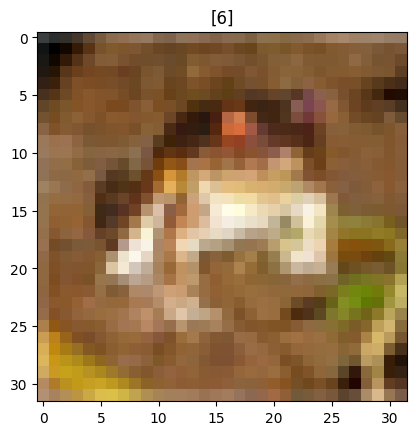

In [ ]:
plt.imshow(X_train[0])
plt.title(y_train[0])

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout

model = Sequential([
  Conv2D(32, (3,3), activation="relu", input_shape=(32,32,3)),
  MaxPooling2D(2,2),
  Conv2D(64, (3,3), activation="relu"),
  MaxPooling2D(2,2),
  Flatten(),
  Dense(128, activation="relu"),
  Dense(10, activation="softmax")
])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 30, 30, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 15, 15, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 13, 13, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 6, 6, 64)          0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 2304)              0         
                                                                 
 dense (Dense)               (None, 128)               2

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import Precision

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights = True
)

In [ ]:
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test), callbacks=[early_stopping])

Epoch 1/10
1563/1563 [==============================] - 11s 5ms/step - loss: 1.9450 - accuracy: 0.3907 - val_loss: 1.3919 - val_accuracy: 0.5031
Epoch 2/10
1563/1563 [==============================] - 6s 4ms/step - loss: 1.2811 - accuracy: 0.5514 - val_loss: 1.2551 - val_accuracy: 0.5568
Epoch 3/10
1563/1563 [==============================] - 7s 4ms/step - loss: 1.1237 - accuracy: 0.6102 - val_loss: 1.1706 - val_accuracy: 0.6006
Epoch 4/10
1563/1563 [==============================] - 6s 4ms/step - loss: 1.0027 - accuracy: 0.6529 - val_loss: 1.1724 - val_accuracy: 0.6157
Epoch 5/10
1563/1563 [==============================] - 7s 4ms/step - loss: 0.9158 - accuracy: 0.6831 - val_loss: 1.1597 - val_accuracy: 0.6225
Epoch 6/10
1563/1563 [==============================] - 6s 4ms/step - loss: 0.8280 - accuracy: 0.7111 - val_loss: 1.1940 - val_accuracy: 0.6298
Epoch 7/10
1563/1563 [==============================] - 7s 4ms/step - loss: 0.7453 - accuracy: 0.7408 - val_loss: 1.1523 - val_accuracy

In [ ]:
model.save("baseline_cnn.keras")

In [ ]:
score = model.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 1.1522889137268066
Test accuracy: 0.6449999809265137


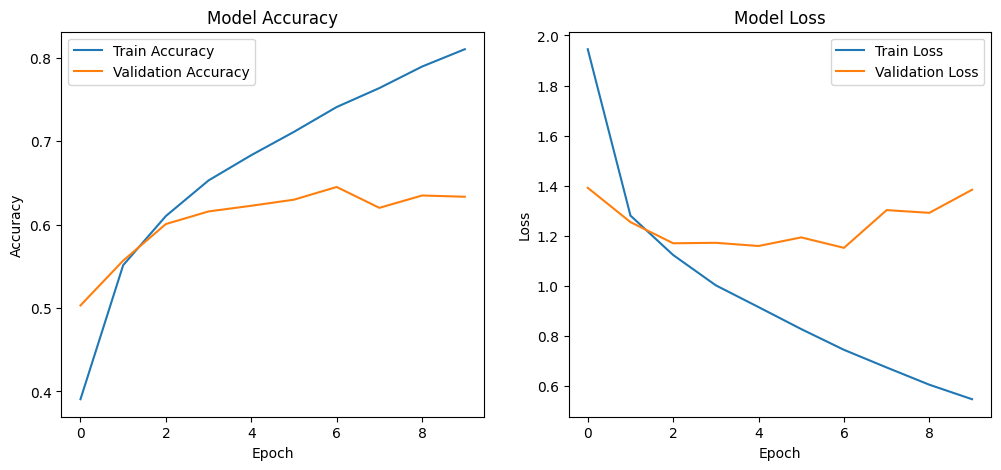

In [ ]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Get predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)  # convert probabilities → class indices

# Individual scores
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall    = recall_score(y_test, y_pred, average="weighted")
f1        = f1_score(y_test, y_pred, average="weighted")

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

313/313 [==============================] - 1s 2ms/step
Accuracy:  0.6450
Precision: 0.6443
Recall:    0.6450
F1 Score:  0.6404


In [ ]:
import tensorflow_hub as hub

mobilenet_v2 ="https://tfhub.dev/google/tf2-preview/mobilenet_v2/classification/4"
inception_v3 = "https://tfhub.dev/google/imagenet/inception_v3/classification/5"

classifier_model = mobilenet_v2

IMAGE_SHAPE = (224, 224)
BATCH_SIZE = 64

import tensorflow as tf
import tensorflow_hub as hub
import numpy as np

def preprocess(image, label):
    image = tf.image.resize(image, [224, 224])
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)) \
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)) \
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)


IMAGE_SHAPE = (224, 224)

classifier = tf.keras.Sequential([
    hub.KerasLayer(classifier_model, input_shape=IMAGE_SHAPE + (3,), trainable=False),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(10, activation="softmax")
])

classifier.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = classifier.fit(train_ds, epochs=10, validation_data=test_ds, callbacks=[early_stopping])

Epoch 1/10
782/782 [==============================] - 73s 86ms/step - loss: 0.6152 - accuracy: 0.7931 - val_loss: 0.4817 - val_accuracy: 0.8297
Epoch 2/10
782/782 [==============================] - 67s 85ms/step - loss: 0.4632 - accuracy: 0.8408 - val_loss: 0.4680 - val_accuracy: 0.8409
Epoch 3/10
782/782 [==============================] - 75s 96ms/step - loss: 0.4188 - accuracy: 0.8535 - val_loss: 0.4467 - val_accuracy: 0.8478
Epoch 4/10
782/782 [==============================] - 66s 84ms/step - loss: 0.3885 - accuracy: 0.8651 - val_loss: 0.4510 - val_accuracy: 0.8448
Epoch 5/10
782/782 [==============================] - 66s 84ms/step - loss: 0.3630 - accuracy: 0.8716 - val_loss: 0.4394 - val_accuracy: 0.8547
Epoch 6/10
782/782 [==============================] - 66s 84ms/step - loss: 0.3448 - accuracy: 0.8782 - val_loss: 0.4467 - val_accuracy: 0.8504
Epoch 7/10
782/782 [==============================] - 75s 96ms/step - loss: 0.3227 - accuracy: 0.8852 - val_loss: 0.4563 - val_accuracy:

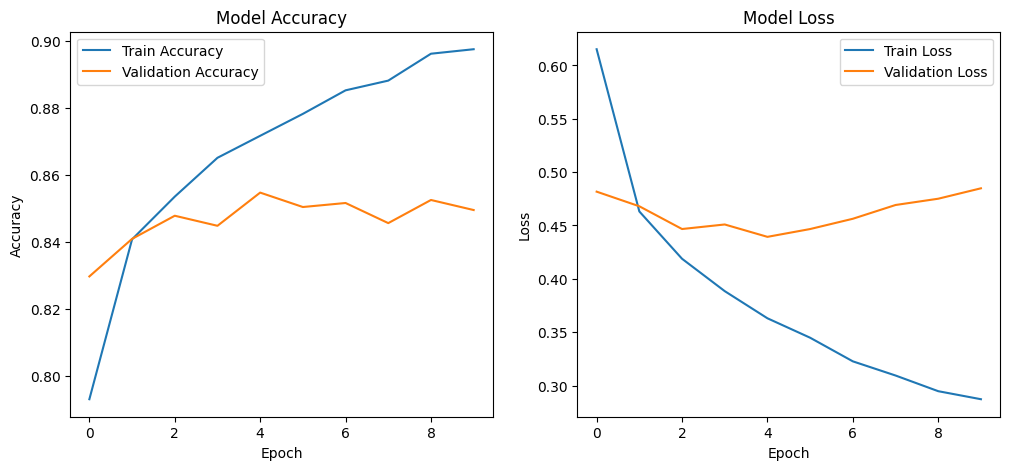

In [ ]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [ ]:
import tensorflow_hub as hub

mobilenet_v2 ="https://tfhub.dev/google/tf2-preview/mobilenet_v2/classification/4"
inception_v3 = "https://tfhub.dev/google/imagenet/inception_v3/classification/5"

classifier_model = inception_v3

IMAGE_SHAPE = (224, 224)
BATCH_SIZE = 64

import tensorflow as tf
import tensorflow_hub as hub
import numpy as np

def preprocess(image, label):
    image = tf.image.resize(image, [224, 224])
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)) \
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)) \
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)


IMAGE_SHAPE = (224, 224)

classifier = tf.keras.Sequential([
    hub.KerasLayer(classifier_model, input_shape=IMAGE_SHAPE + (3,), trainable=False),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(10, activation="softmax")
])

classifier.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = classifier.fit(train_ds, epochs=10, validation_data=test_ds, callbacks=[early_stopping])

Epoch 1/10
782/782 [==============================] - 145s 175ms/step - loss: 0.5898 - accuracy: 0.8133 - val_loss: 0.4438 - val_accuracy: 0.8474
Epoch 2/10
782/782 [==============================] - 133s 170ms/step - loss: 0.4267 - accuracy: 0.8569 - val_loss: 0.4272 - val_accuracy: 0.8531
Epoch 3/10
782/782 [==============================] - 133s 170ms/step - loss: 0.3847 - accuracy: 0.8694 - val_loss: 0.4202 - val_accuracy: 0.8606
Epoch 4/10
782/782 [==============================] - 152s 195ms/step - loss: 0.3537 - accuracy: 0.8783 - val_loss: 0.4201 - val_accuracy: 0.8622
Epoch 5/10
782/782 [==============================] - 134s 171ms/step - loss: 0.3316 - accuracy: 0.8856 - val_loss: 0.4299 - val_accuracy: 0.8615
Epoch 6/10
782/782 [==============================] - 133s 169ms/step - loss: 0.3090 - accuracy: 0.8929 - val_loss: 0.4346 - val_accuracy: 0.8640
Epoch 7/10
782/782 [==============================] - 152s 194ms/step - loss: 0.2936 - accuracy: 0.8988 - val_loss: 0.4485 -

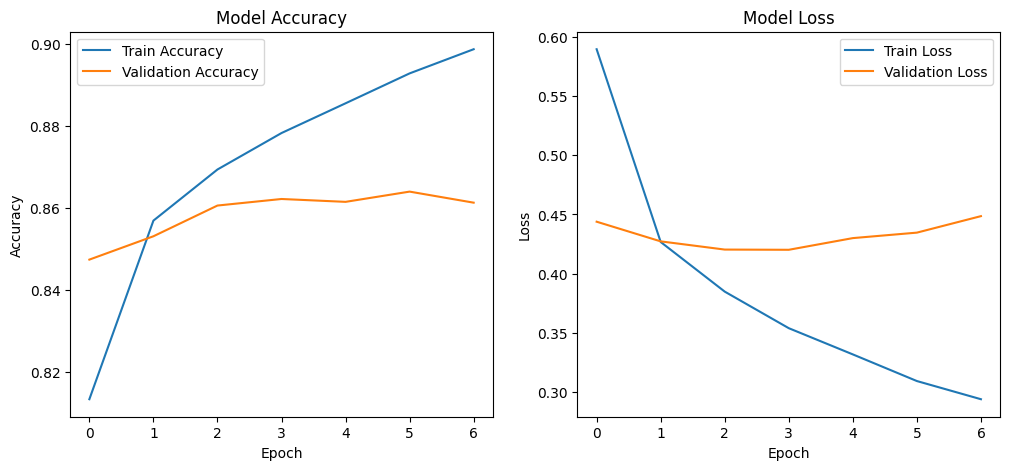

In [ ]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [5]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping

IMAGE_SHAPE = (96, 96)  # Smaller than 224x224 — faster, better for upscaled 32px images
BATCH_SIZE = 64

# ── Load CIFAR-10 ────────────────────────────────────────────────
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# ── Data pipeline ────────────────────────────────────────────────
def preprocess(image, label):
    image = tf.image.resize(image, IMAGE_SHAPE)       # 32x32 → 96x96 (less interpolation distortion)
    image = preprocess_input(image)                    # ResNet50 ImageNet-style normalization
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)) \
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE) \
    .shuffle(10000) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)) \
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)

# ── Model ────────────────────────────────────────────────────────
base_model = ResNet50(
    input_shape=IMAGE_SHAPE + (3,),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

classifier = tf.keras.Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(10, activation="softmax")
])

classifier.summary()

# ── Phase 1: Train head only ─────────────────────────────────────
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

classifier.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_head = classifier.fit(
    train_ds,
    epochs=10,
    validation_data=test_ds,
    callbacks=[early_stopping]
)

# ── Phase 2: Fine-tune top ResNet50 layers ───────────────────────
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

classifier.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # much lower lr to preserve pretrained weights
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_finetune = classifier.fit(
    train_ds,
    epochs=10,
    validation_data=test_ds,
    callbacks=[early_stopping]
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 3, 3, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,851,274 (90.99 MB)

 Trainable params: 263,562 (1.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 64s 62ms/step - accuracy: 0.8060 - loss: 0.5784 - val_accuracy: 0.8443 - val_loss: 0.4546
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - accuracy: 0.8575 - loss: 0.4160 - val_accuracy: 0.8575 - val_loss: 0.4129
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 47ms/step - accuracy: 0.8748 - loss: 0.3579 - val_accuracy: 0.8602 - val_loss: 0.4070
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 47ms/step - accuracy: 0.8871 - loss: 0.3198 - val_accuracy: 0.8638 - val_loss: 0.4024
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 47s 52ms/step - accuracy: 0.8974 - loss: 0.2842 - val_accuracy: 0.8677 - val_loss: 0.4078
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 45s 53ms/step - accuracy: 0.9076 - loss: 0.2598 - val_accuracy: 0.8641 - val_loss: 0.4194
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.9156 - loss: 0.2321 - val_accuracy: 0.8644 - val_loss: 0.4343
Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 97s 93ms/step - accuracy: 0.8782 - loss: 0.3526 - 

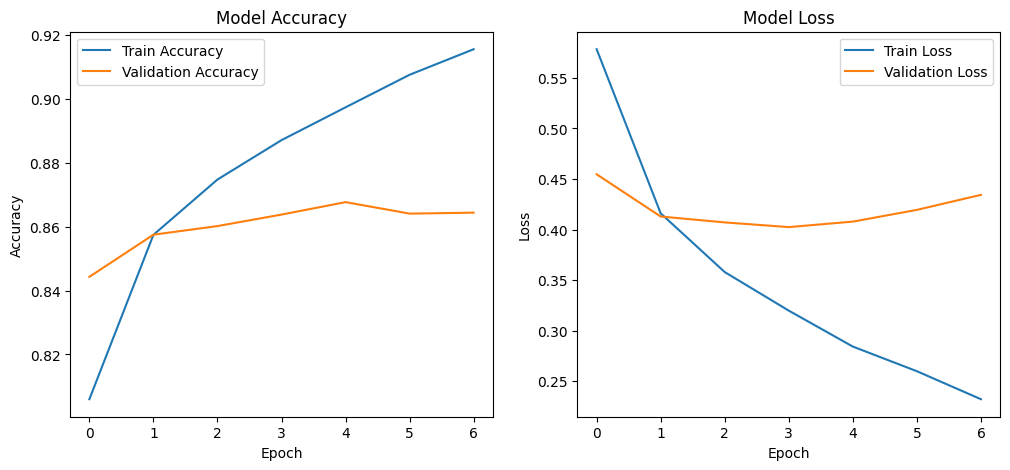

In [7]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_head.history['accuracy'], label='Train Accuracy')
plt.plot(history_head.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_head.history['loss'], label='Train Loss')
plt.plot(history_head.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


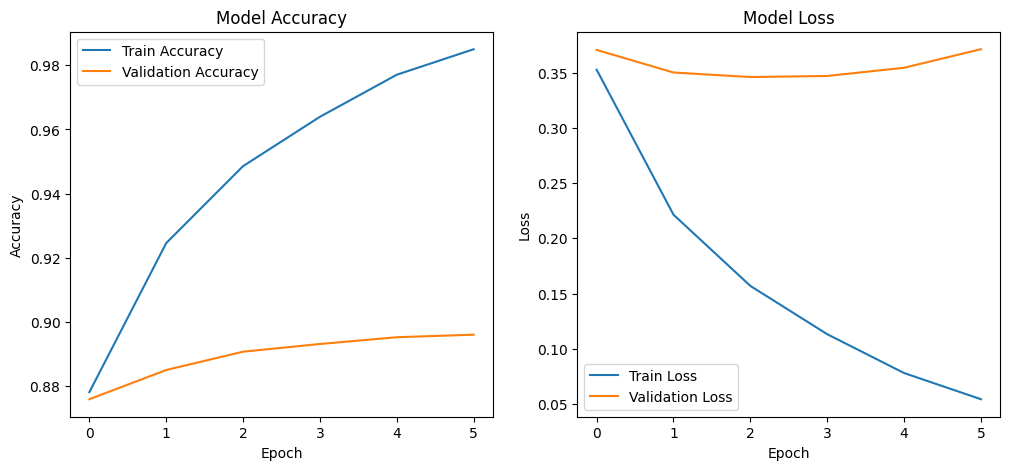

In [8]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_finetune.history['accuracy'], label='Train Accuracy')
plt.plot(history_finetune.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_finetune.history['loss'], label='Train Loss')
plt.plot(history_finetune.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()
